In [1]:
##### Creates maps of capital and labor stock (national & sub-national)

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import sub-national data

sub_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")

sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# Import country data

country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/map_capital_labor"

In [3]:
### Data prep

# align crs

crs = "ESRI:54042"

sub_geo_capital = sub_geo_capital.to_crs(crs)
sub_geo_labor = sub_geo_labor.to_crs(crs)
country_shp = country_shp.to_crs(crs)

# prep country shp 
country_shp = country_shp.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='inner')

# join data to shape
sub_geo_capital = sub_geo_capital.merge(sub_capital, on='PROJ_ID', how='inner')
sub_geo_labor = sub_geo_labor.merge(sub_labor, on='PROJ_ID', how='inner')

country_shp = country_shp.merge(country_intensities, on='ISO3', how='outer')

# change units
sub_geo_capital['ag_capital_stock_mUSD_nominal'] = sub_geo_capital['ag_capital_stock_USD_nominal'] / 1e6

In [4]:
##### Create groupings for data

# capital 
cap_bins = [0, 5, 10, 50, 300, float('inf')]
cap_labels = ['0-5', '5-10', '10-50', '50-300', '300+']

sub_geo_capital['bucket'] = pd.cut(
    sub_geo_capital['ag_capital_stock_mUSD_nominal'],
    bins=cap_bins,
    labels=cap_labels
)

# labor 
lab_bins = [0, 250, 500, 1000, 3000, float('inf')]
lab_labels = ['0-250', '250-500', '500-1,000', '1,000-3,000', '3,000+']

sub_geo_labor['bucket'] = pd.cut(
    sub_geo_labor['ag_jobs'],
    bins=lab_bins,
    labels=lab_labels
)


In [5]:
sub_geo_labor['ag_jobs'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

0.1       93.447399
0.2      231.114904
0.3      364.982702
0.4      518.786867
0.5      711.835930
0.6     1021.888889
0.7     1544.820676
0.8     2685.798467
0.9    13636.839399
Name: ag_jobs, dtype: float64

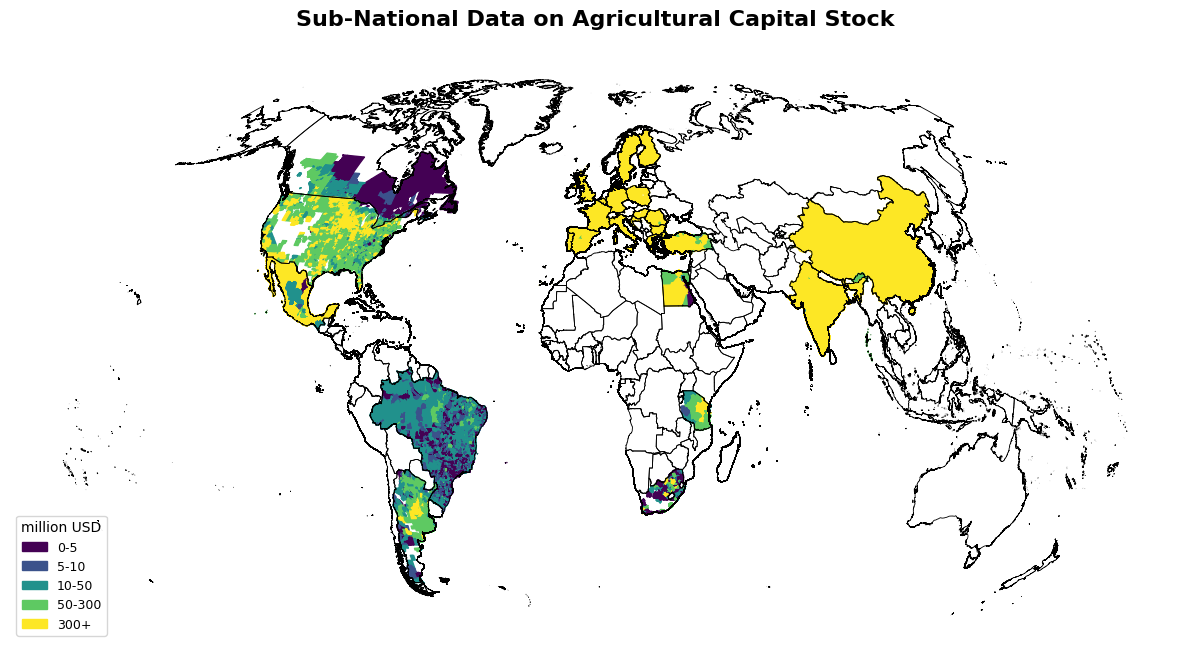

In [6]:
##### Plot sub-national capital stock 

colors = plt.cm.viridis([i / (len(cap_labels) - 1) for i in range(len(cap_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_capital.plot(
    column='bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=cap_labels[i]) for i in range(len(cap_labels))]
ax.legend(
    handles=patches,
    title="million USD",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_capital_stock.png", dpi=300, bbox_inches='tight')

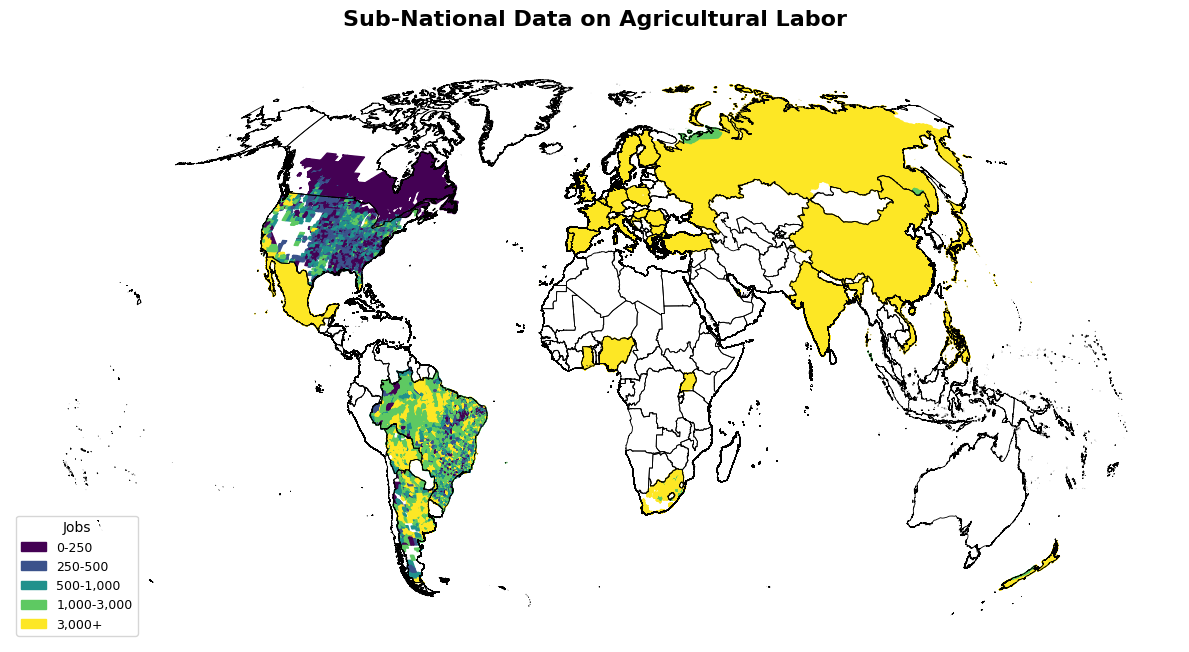

In [7]:
##### Plot sub-national labor  

colors = plt.cm.viridis([i / (len(lab_labels) - 1) for i in range(len(lab_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_labor.plot(
    column='bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=lab_labels[i]) for i in range(len(lab_labels))]
ax.legend(
    handles=patches,
    title="Jobs",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Labor", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_labor.png", dpi=300, bbox_inches='tight')

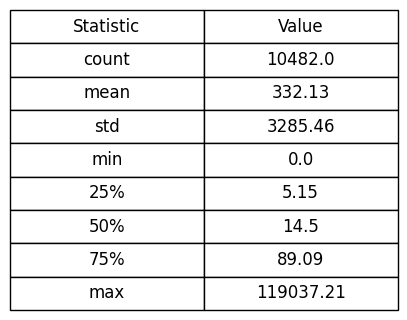

In [8]:
### Get basic stats 

stats = sub_geo_capital['ag_capital_stock_mUSD_nominal'].describe().round(2)  

stats_df = pd.DataFrame(stats).reset_index()
stats_df.columns = ['Statistic', 'Value']

### Create fig of table
fig, ax = plt.subplots(figsize=(5, 2))  

ax.axis('off')

# Create table
table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling 
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)  

plt.show()

In [9]:
##### Creat groupings for country data

# capital 
cap_bins = [0, 500, 5000, 20000, 50000, float('inf')]
cap_labels = ['0-500', '500-5,000', '5,000-20,000', '20,000-50,000', '50,000+']

country_shp['cap_bucket'] = pd.cut(
    country_shp['ag_capital_stock_mil_USD_nominal'],
    bins=cap_bins,
    labels=cap_labels
)

# labor 
lab_bins = [0, 75, 300, 1000, 5000, float('inf')]
lab_labels = ['0-75', '75-300', '300-1,000', '1,000-5,000', '5,000+']

country_shp['lab_bucket'] = pd.cut(
    country_shp['ag_labor_thousands_2020'],
    bins=lab_bins,
    labels=lab_labels
)


In [10]:
country_shp['ag_labor_thousands_2020'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

0.1      12.367154
0.2      46.458370
0.3     114.759137
0.4     236.374761
0.5     492.977312
0.6     890.426284
0.7    1749.728611
0.8    3391.330915
0.9    6296.062572
Name: ag_labor_thousands_2020, dtype: float64

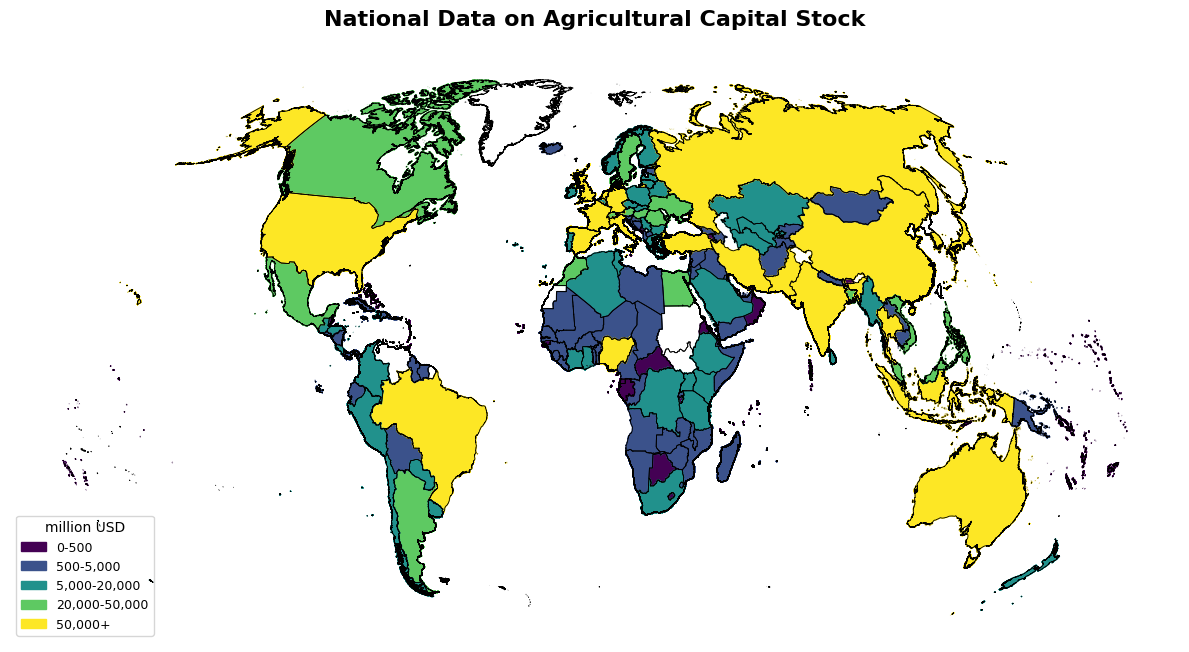

In [11]:
##### Plot national capital stock 

colors = plt.cm.viridis([i / (len(cap_labels) - 1) for i in range(len(cap_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
country_shp.plot(
    column='cap_bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=cap_labels[i]) for i in range(len(cap_labels))]
ax.legend(
    handles=patches,
    title="million USD",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("National Data on Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/national_capital_stock.png", dpi=300, bbox_inches='tight')

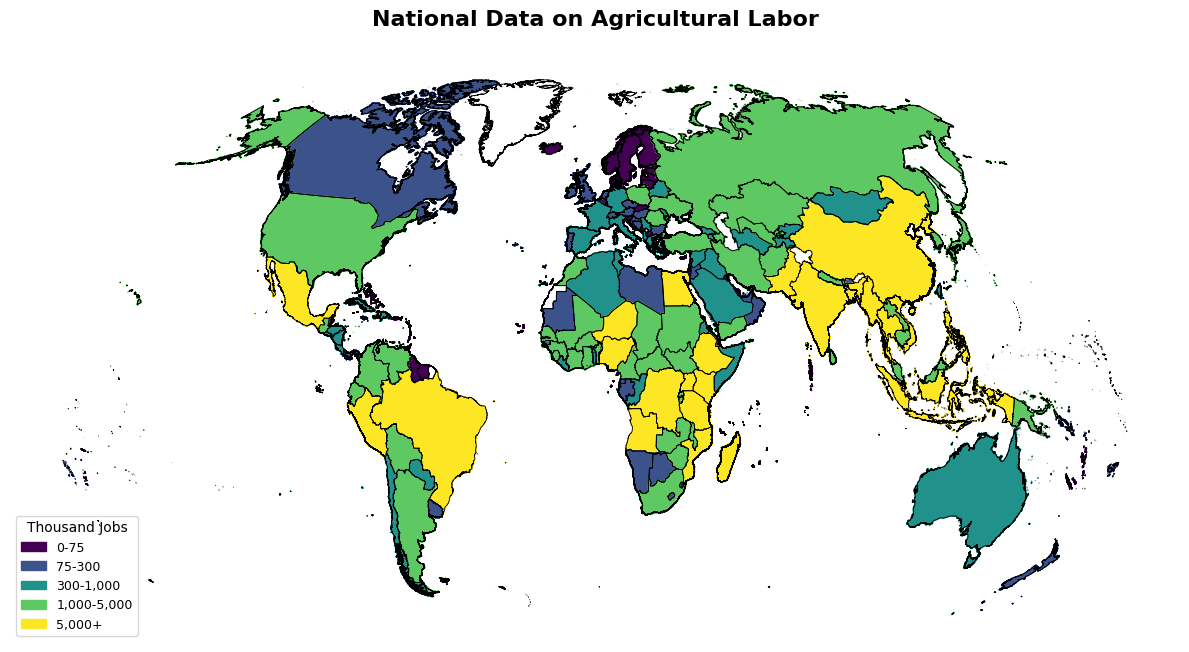

In [12]:
##### Plot national labor  

colors = plt.cm.viridis([i / (len(lab_labels) - 1) for i in range(len(lab_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
country_shp.plot(
    column='lab_bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=lab_labels[i]) for i in range(len(lab_labels))]
ax.legend(
    handles=patches,
    title="Thousand Jobs",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("National Data on Agricultural Labor", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/national_labor.png", dpi=300, bbox_inches='tight')